In [49]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
train = pd.read_csv(Path("/home/legionlinux/miniconda3/envs/torchenv/__INIT__/Kaggle/birdclef-2026/data/raw/train.csv"))

In [2]:
train

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35544,yeofly1,[],['call'],-6.7281,-76.4181,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/762473/download,yeofly1/XC762473.ogg,XC
35545,yeofly1,[],"['call', ' song']",-16.0538,-49.6040,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,JAYRSON ARAUJO DE OLIVEIRA,by-nc-sa,5.0,https://xeno-canto.org/818328/download,yeofly1/XC818328.ogg,XC
35546,yeofly1,[],['song'],5.9002,-74.8485,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,Jerome Fischer,by-nc-sa,4.0,https://xeno-canto.org/425545/download,yeofly1/XC425545.ogg,XC
35547,yeofly1,[],['song'],3.3821,-61.4464,Tolmomyias sulphurescens,Yellow-olive Flatbill,Aves,16567,GABRIEL LEITE,by-nc-sa,4.0,https://xeno-canto.org/456230/download,yeofly1/XC456230.ogg,XC


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   primary_label     35549 non-null  object 
 1   secondary_labels  35549 non-null  object 
 2   type              35549 non-null  object 
 3   latitude          35549 non-null  float64
 4   longitude         35549 non-null  float64
 5   scientific_name   35549 non-null  object 
 6   common_name       35549 non-null  object 
 7   class_name        35549 non-null  object 
 8   inat_taxon_id     35549 non-null  int64  
 9   author            35549 non-null  object 
 10  license           35549 non-null  object 
 11  rating            35549 non-null  float64
 12  url               35549 non-null  object 
 13  filename          35549 non-null  object 
 14  collection        35549 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 4.1+ MB


In [22]:
train_cat = train.select_dtypes(include=['object'])
train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   primary_label     35549 non-null  object
 1   secondary_labels  35549 non-null  object
 2   type              35549 non-null  object
 3   scientific_name   35549 non-null  object
 4   common_name       35549 non-null  object
 5   class_name        35549 non-null  object
 6   author            35549 non-null  object
 7   license           35549 non-null  object
 8   url               35549 non-null  object
 9   filename          35549 non-null  object
 10  collection        35549 non-null  object
dtypes: object(11)
memory usage: 3.0+ MB


In [23]:
train_num = train.select_dtypes(include=['int64', 'float64'])
train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35549 entries, 0 to 35548
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       35549 non-null  float64
 1   longitude      35549 non-null  float64
 2   inat_taxon_id  35549 non-null  int64  
 3   rating         35549 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 1.1 MB


primary_label
116570       1
23150        1
516975       1
23724        1
209233       2
          ... 
houspa     496
soulap1    497
fepowl     497
banana     498
rubthr1    499
Name: count, Length: 206, dtype: int64


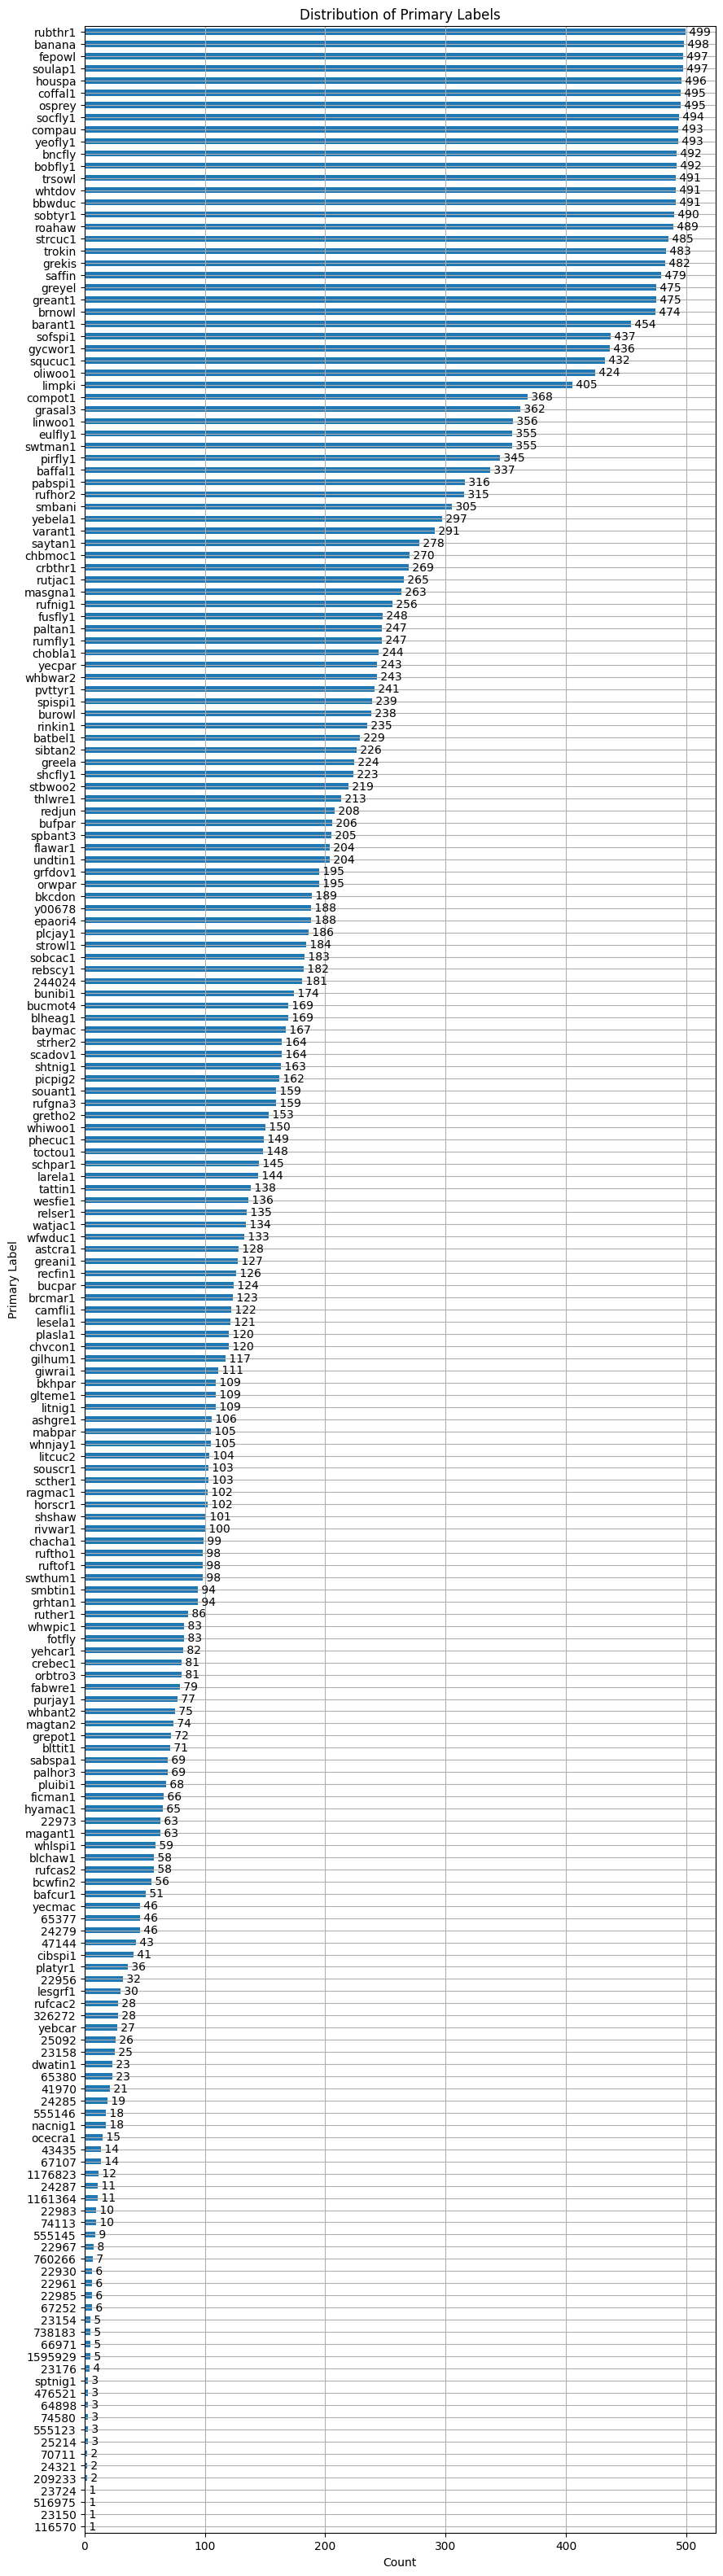

In [68]:
counts = train_cat['primary_label'].value_counts(ascending=True)

print(counts)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Primary Label')
ax.set_title('Distribution of Primary Labels')

plt.grid(True)
plt.show()

In [44]:
train_cat[['primary_label', 'secondary_labels']].value_counts()

primary_label  secondary_labels              
houspa         []                                494
osprey         []                                493
compau         []                                474
soulap1        []                                470
brnowl         []                                470
                                                ... 
linwoo1        ['orwpar', 'saffin', 'yecpar']      1
               ['masgna1']                         1
               ['lesela1']                         1
               ['grfdov1']                         1
limpki         ['undtin1']                         1
Name: count, Length: 3762, dtype: int64

In [45]:
train_cat[['primary_label', 'secondary_labels', 'type']].value_counts()

primary_label  secondary_labels                                        type                     
houspa         []                                                      []                           386
osprey         []                                                      []                           376
brnowl         []                                                      []                           357
greyel         []                                                      []                           312
grekis         []                                                      []                           305
                                                                                                   ... 
yeofly1        ['whtdov']                                              ['call']                       1
               ['whtdov', 'soulap1', 'grekis']                         ['song']                       1
               ['whtdov', 'plasla1']                                   

In [46]:
train_cat['type'].value_counts()

type
[]                               12975
['song']                         10376
['call']                          6205
['call', ' song']                 1458
['flight call']                    711
                                 ...  
['song', ' 2 song types']            1
['call', ' call variation']          1
['song', ' human voice']             1
['call', ' single call note']        1
['call', ' calls (2 types)']         1
Name: count, Length: 755, dtype: int64

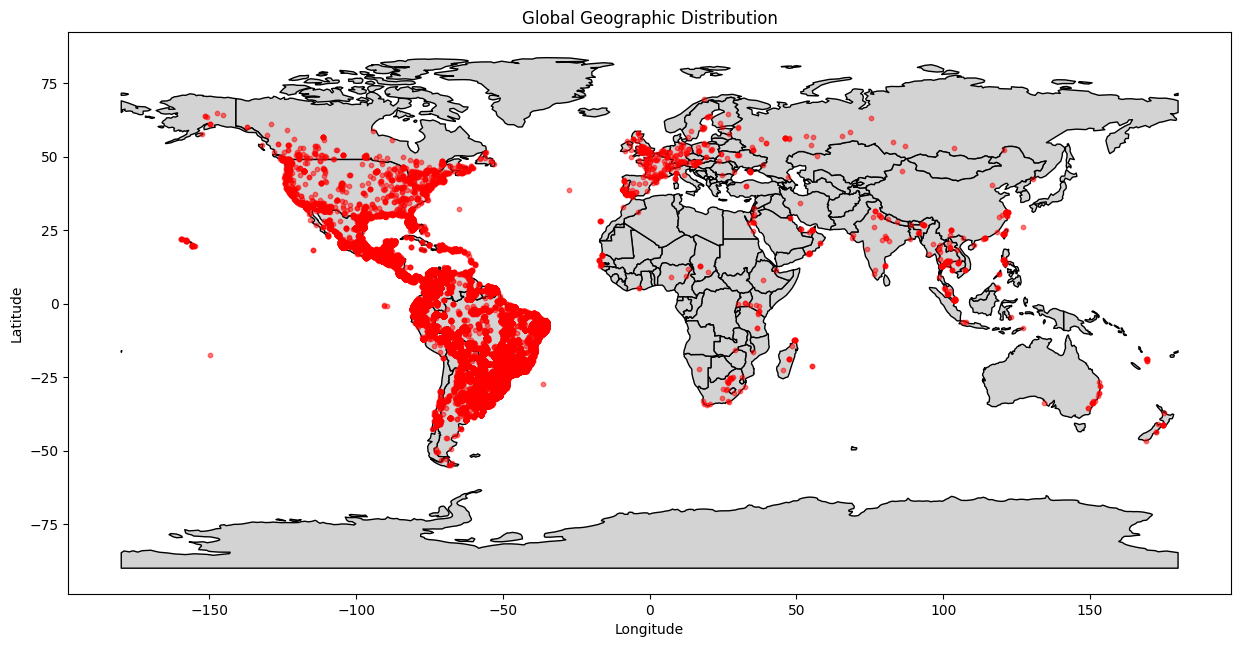

In [51]:
# Load world map from Natural Earth
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Create figure
fig, ax = plt.subplots(figsize=(15, 10))

# Plot world map
world.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black'
)

# Plot latitude/longitude points
ax.scatter(
    train_num['longitude'],
    train_num['latitude'],
    s=10,
    color='red',
    alpha=0.5
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Geographic Distribution")

plt.show()

In [52]:
train_cat[['scientific_name', 'common_name', 'class_name']].value_counts()

scientific_name             common_name                 class_name
Turdus rufiventris          Rufous-bellied Thrush       Aves          499
Coereba flaveola            Bananaquit                  Aves          498
Glaucidium brasilianum      Ferruginous Pygmy Owl       Aves          497
Vanellus chilensis          Southern Lapwing            Aves          497
Passer domesticus           House Sparrow               Aves          496
                                                                     ... 
Leptodactylus macrosternum  Cei's White-lipped Frog     Amphibia        2
Caiman yacare               Southern Spectacled Caiman  Reptilia        1
Phyllomedusa sauvagii       Waxy Monkey Tree Frog       Amphibia        1
Sapajus cay                 Hooded Capuchin             Mammalia        1
Physalaemus centralis       Central Dwarf Frog          Amphibia        1
Name: count, Length: 206, dtype: int64

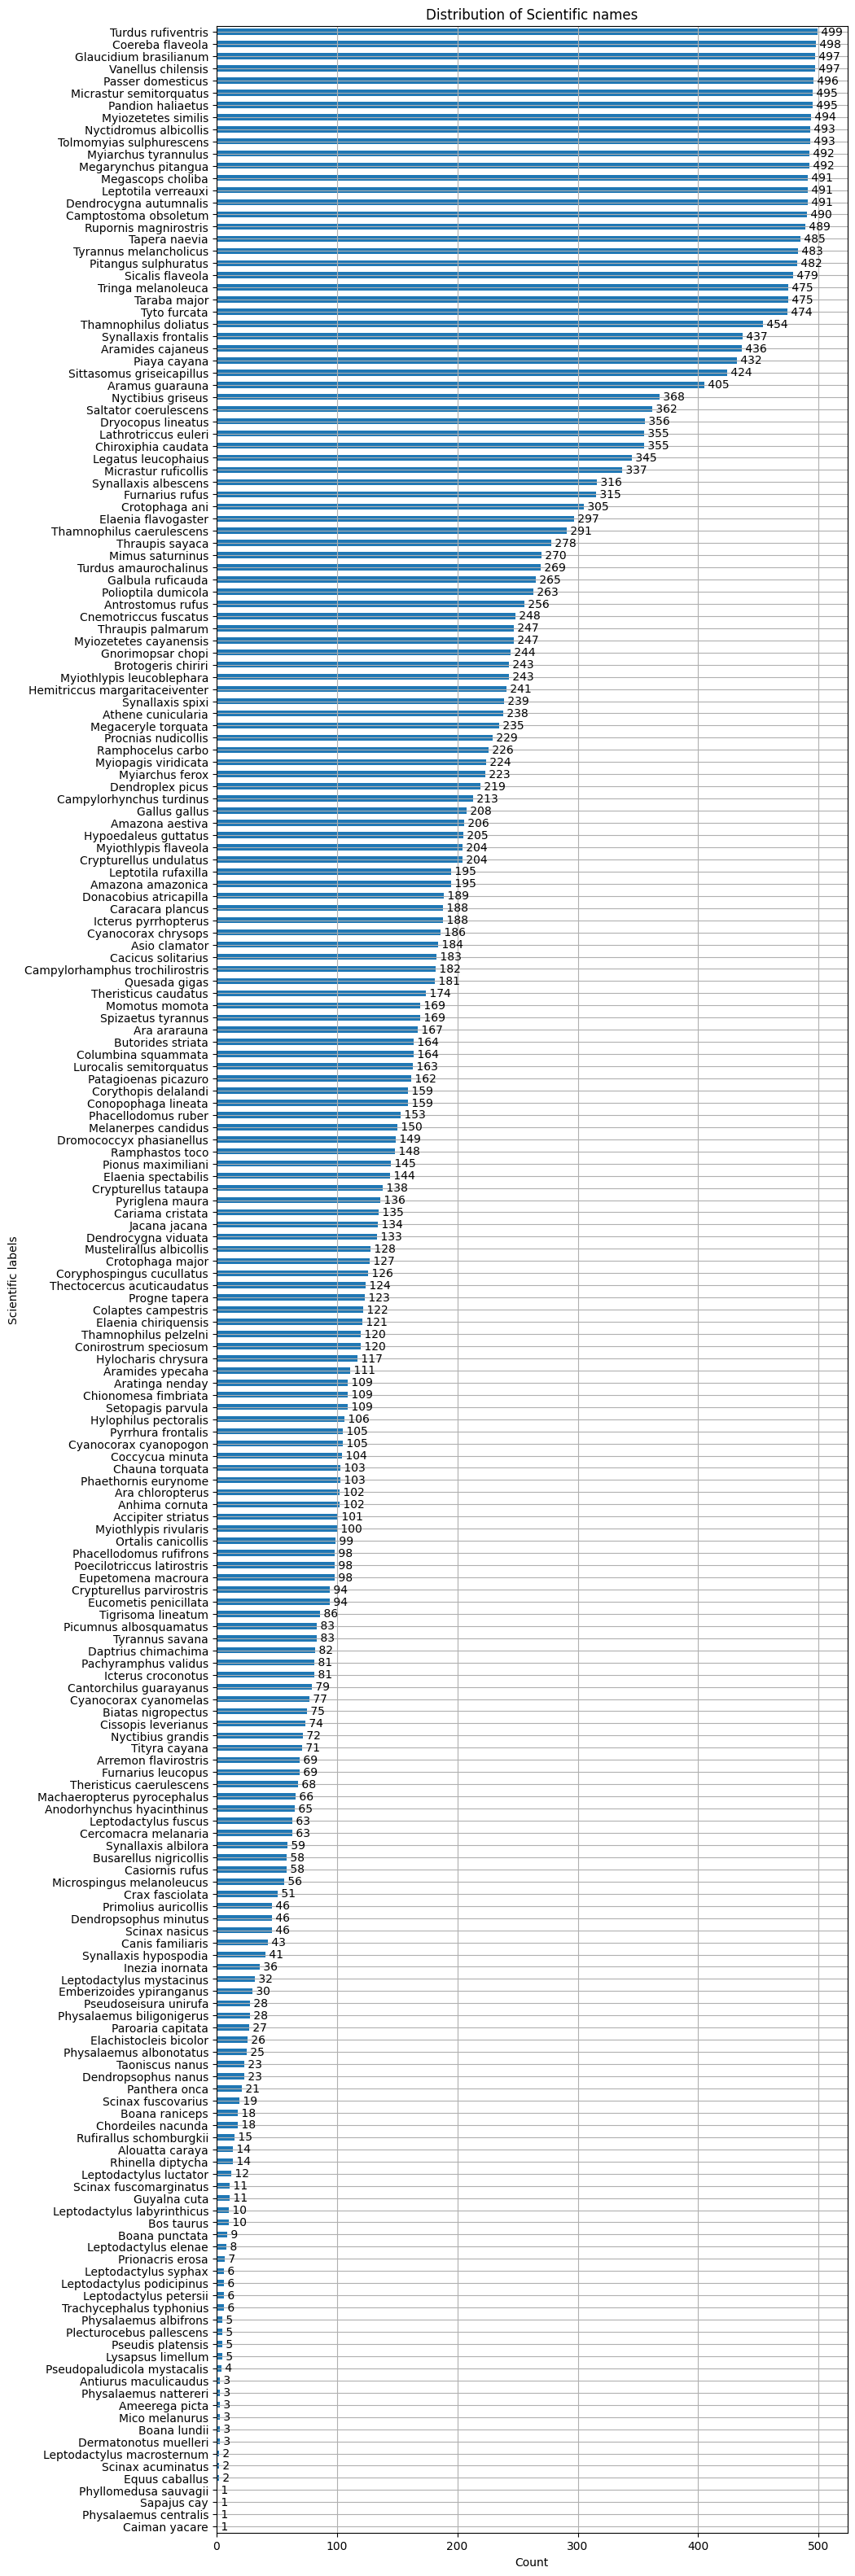

In [62]:
counts = train_cat['scientific_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Scientific labels')
ax.set_title('Distribution of Scientific names')

plt.grid(True)
plt.show()

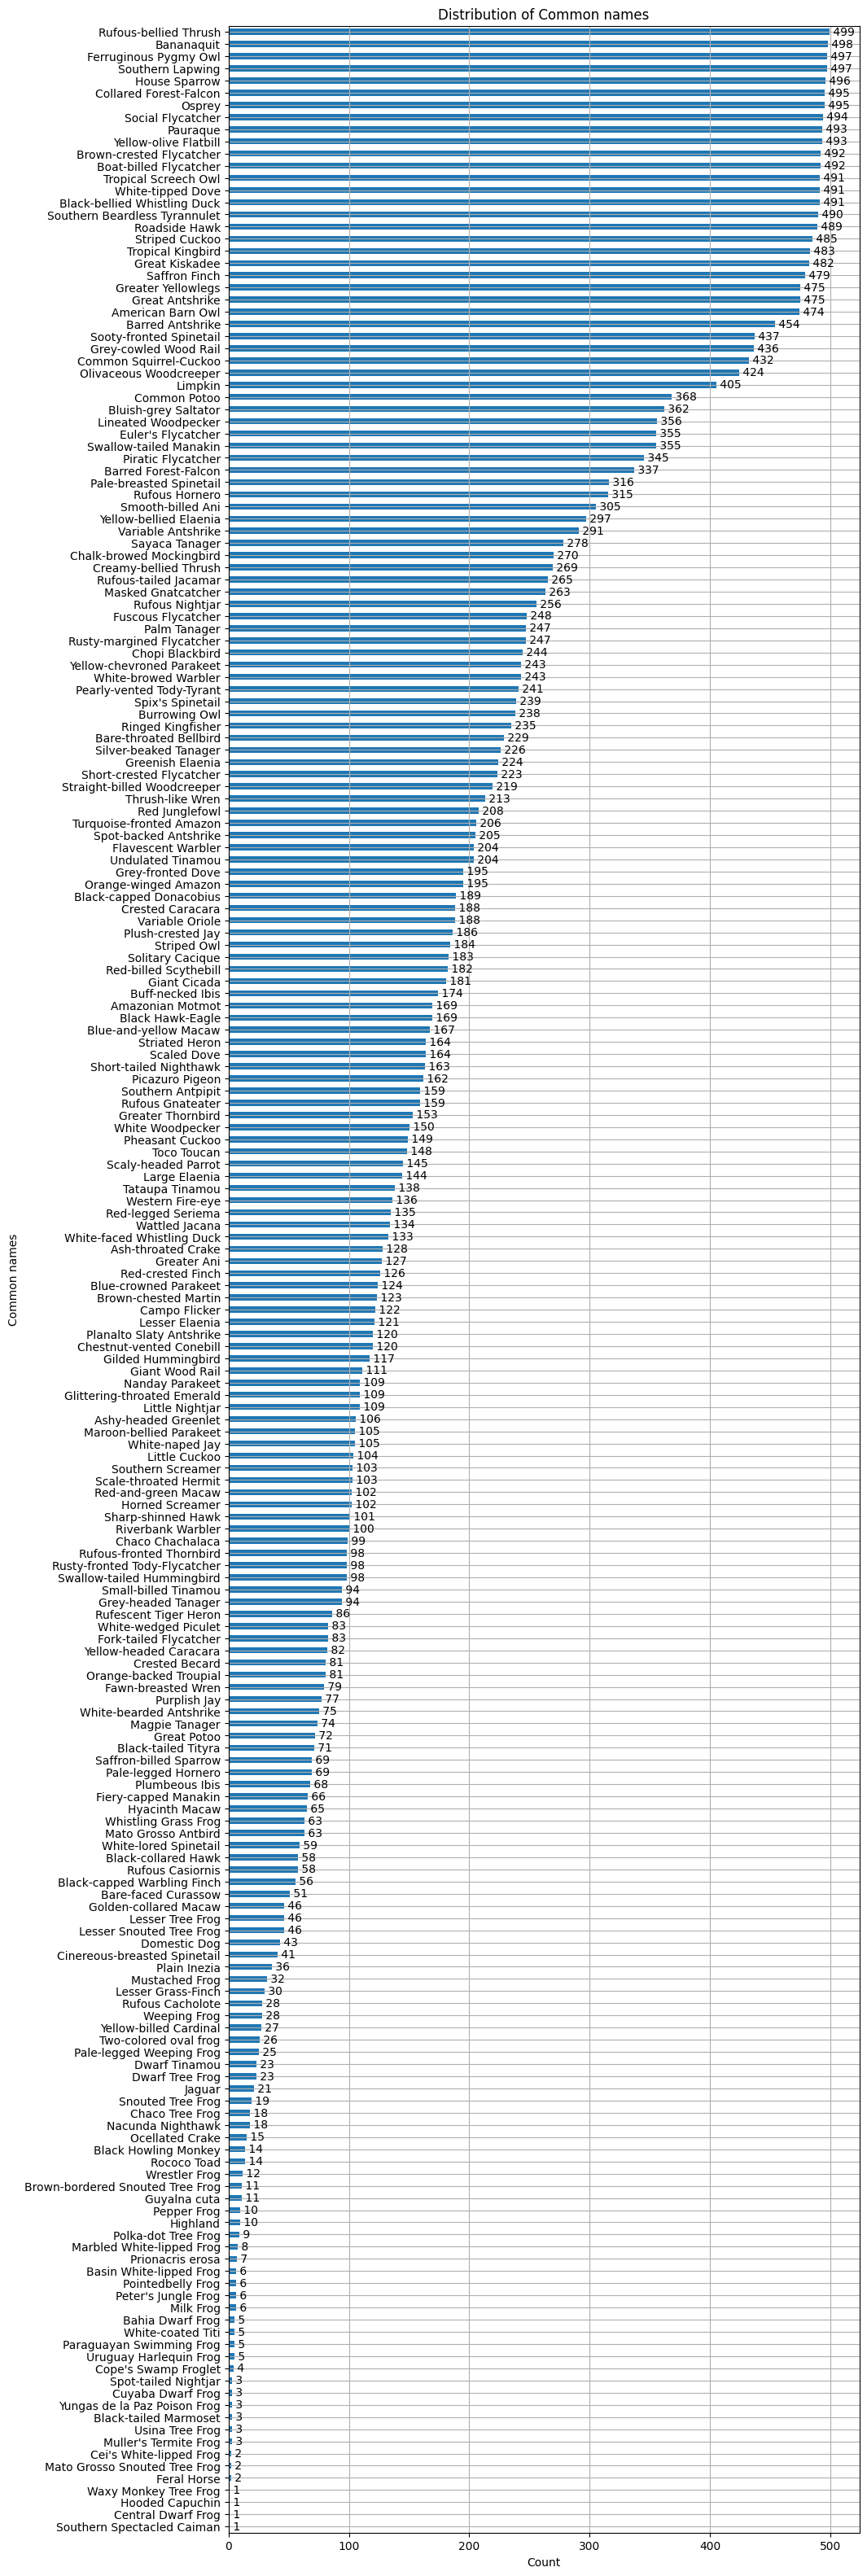

In [63]:
counts = train_cat['common_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Common names')
ax.set_title('Distribution of Common names')

plt.grid(True)
plt.show()

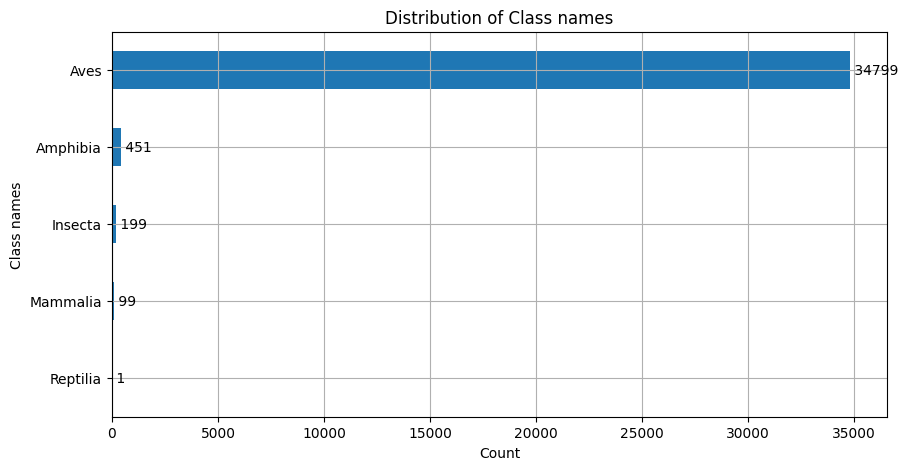

In [64]:
counts = train_cat['class_name'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Class names')
ax.set_title('Distribution of Class names')

plt.grid(True)
plt.show()

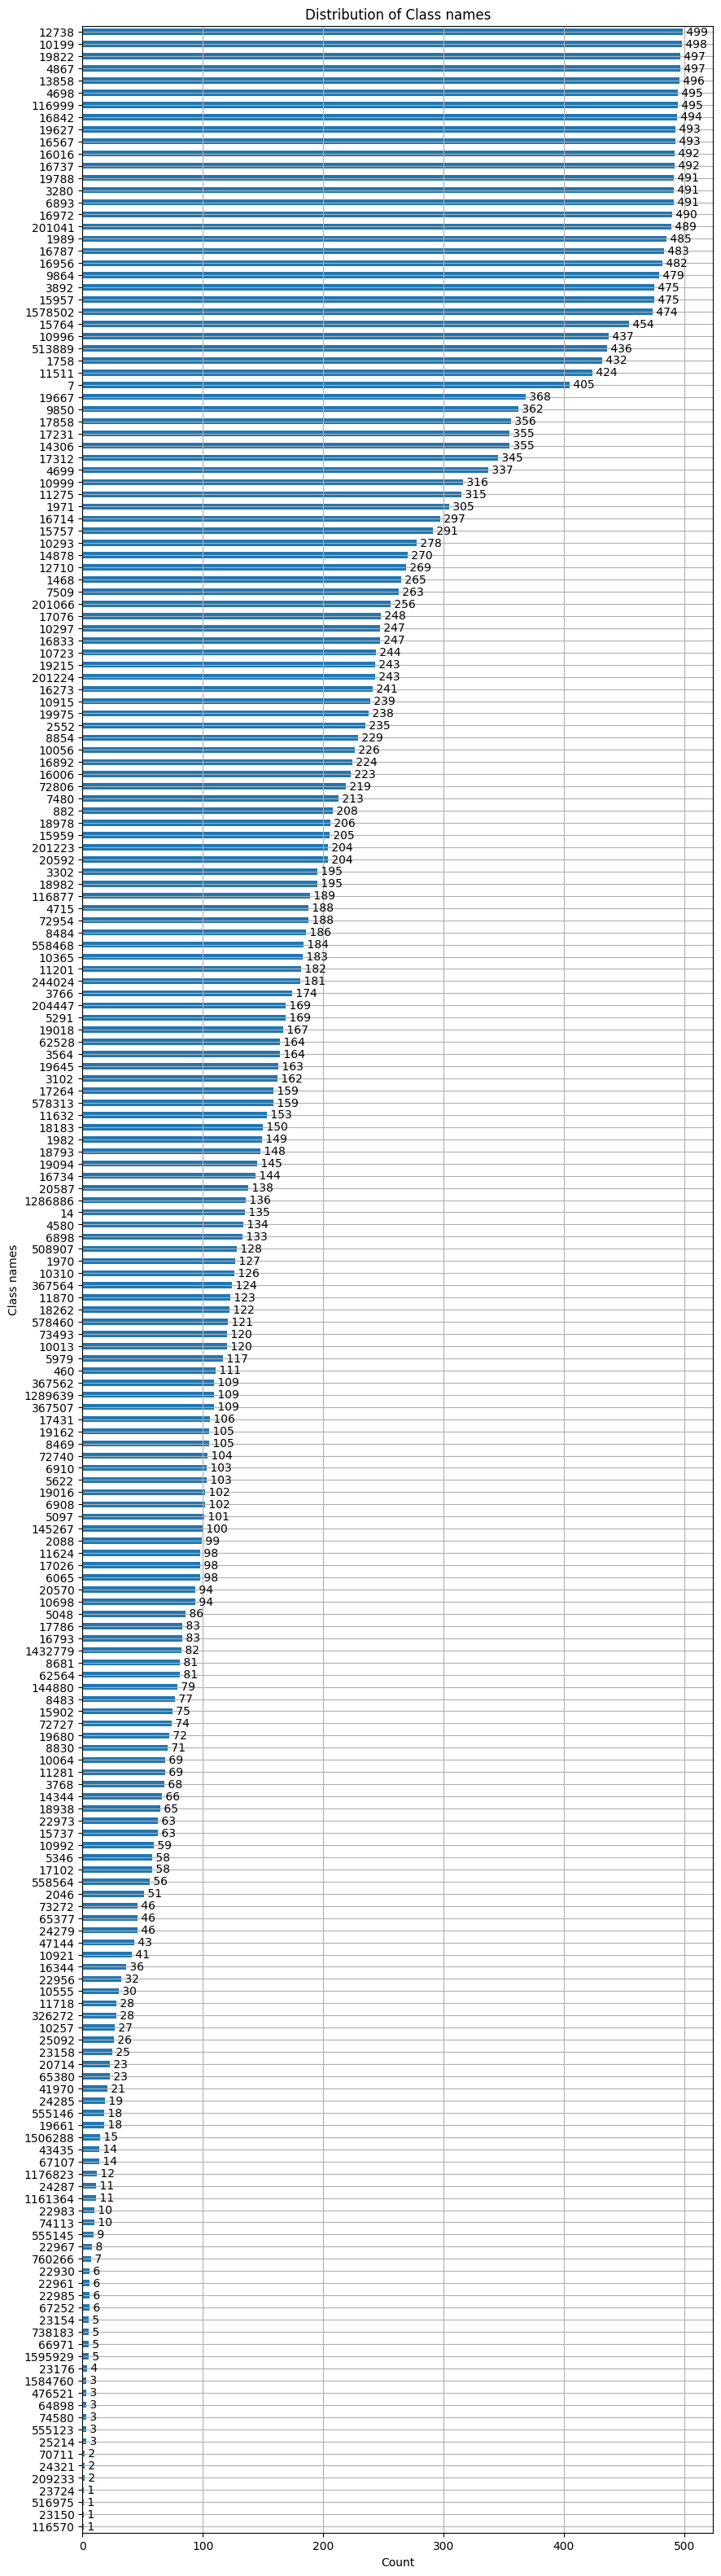

In [73]:
counts = train['inat_taxon_id'].value_counts(ascending=True)

fig, ax = plt.subplots(figsize=(10, 40))

counts.plot(kind='barh', ax=ax)

# Put count at the front/end of each bar
for i, v in enumerate(counts.values):
    ax.text(
        v,            # end of bar
        i,            # bar position
        f' {v}',      # count text
        va='center',
        ha='left'
    )

ax.set_xlabel('Count')
ax.set_ylabel('Class names')
ax.set_title('Distribution of Class names')

plt.grid(True)
plt.show()

<Axes: ylabel='collection'>

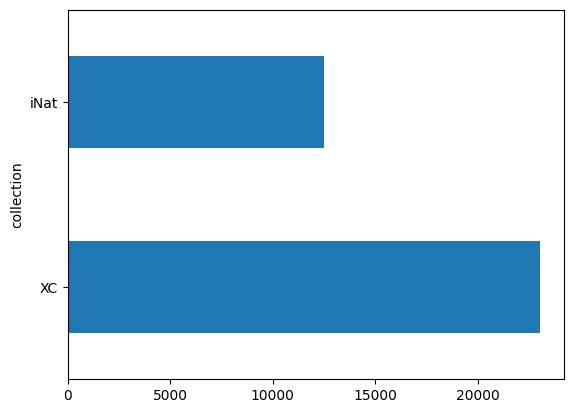

In [70]:
train['collection'].value_counts().plot(kind='barh')